<a href="https://colab.research.google.com/github/LIBY70/Data-Analysis/blob/main/ida_week10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab10: 다변량 분석 — PCA & K-means 클러스터링

본 실습 자료는 『배워서 바로 써먹는 데이터 분석 with 파이썬』 (설진욱, 생능북스)의 내용을 참고하여 제작되었습니다.

## 0. 라이브러리 불러오기

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

### 한글 폰트 설정

In [2]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (24.6 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [3]:
import platform

if platform.system() == 'Darwin':       # macOS
    mpl.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':    # Windows
    mpl.rc('font', family='Malgun Gothic')
else:                                   # Linux / Colab
    import matplotlib.font_manager as fm
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    mpl.rc('font', family='NanumGothic')

mpl.rc('axes', unicode_minus=False)
print('폰트 설정 완료:', mpl.rcParams['font.family'])

폰트 설정 완료: ['NanumGothic']


---
## PART 1. 주성분분석 (PCA)

**목적**: 13개의 화학 성분 변수를 소수의 주성분(PC)으로 압축하여
- 차원의 저주 해소 — 시각화·연산 효율 향상
- 다중공선성 제거 — 독립적인 새 축 생성
- 이후 K-means 군집화의 전처리 단계로 활용

**핵심 아이디어**: 데이터의 **분산이 가장 큰 방향**으로 새 축(주성분)을 생성하고,
기존 변수들의 **선형결합**으로 주성분을 구성한다.

$$\text{PC}_k = a_{k1}X_1 + a_{k2}X_2 + \cdots + a_{k,p}X_p = \mathbf{a}_k^\top \mathbf{X}$$

- $a_{kj}$: 적재량(loading) — $j$번째 변수가 $k$번째 주성분에 기여하는 가중치
- $\lambda_k = \text{Var}(\text{PC}_k)$: **고유값(eigenvalue)** — 해당 주성분이 설명하는 분산 크기
- 분산 설명 비율: $\dfrac{\lambda_k}{\sum_{j=1}^{p} \lambda_j}$

### 1-1. 데이터 준비 — sklearn 와인 데이터셋

**데이터 개요**
- 표본: 178개, 이탈리아산 와인 **3가지 품종**
- 변수: **13가지 화학 성분** (알코올, 플라보노이드, 색상강도, 프롤린 등)
- 전처리 필요: 변수마다 단위·스케일이 다름 → **표준화 필수**

In [4]:
from sklearn.datasets import load_wine
wine = load_wine()

wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [5]:
wine.data

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]])

In [6]:
# 영문 변수명 → 한글 매핑
feature_names_kr = [
    '알코올', '사과산', '회분', '회분 알칼리도', '마그네슘',
    '총 페놀', '플라보노이드', '비플라보노이드 페놀',
    '프로안토시아닌', '색상 강도', '색조', 'OD280/OD315', '프롤린'
]

df = pd.DataFrame(wine.data, columns=feature_names_kr)
df['품종'] = wine.target
df['품종명'] = df['품종'].map({0: '품종1', 1: '품종2', 2: '품종3'})
df.head()

,알코올,사과산,회분,회분 알칼리도,마그네슘,총 페놀,플라보노이드,비플라보노이드 페놀,프로안토시아닌,색상 강도,색조,OD280/OD315,프롤린,품종,품종명
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,품종1
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,품종1
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,품종1
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,품종1
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,품종1


In [7]:
df.shape

(178, 15)

In [8]:
df['품종명'].value_counts().sort_index()

,count
품종명,
품종1,59
품종2,71
품종3,48


### 1-2. 변수 기초 통계 — 스케일 차이 확인

PCA 적용 전, 변수별 평균과 표준편차를 확인한다.  
단위가 다르면 스케일이 큰 변수가 주성분을 지배하므로 **표준화**가 필수적

In [9]:
stats_df = df[feature_names_kr].agg(['mean', 'std']).T
stats_df.columns = ['평균', '표준편차']
print("변수별 기초 통계 — 스케일 차이 확인")
stats_df.round(2)

변수별 기초 통계 — 스케일 차이 확인


,평균,표준편차
알코올,13.00,0.81
사과산,2.34,1.12
회분,2.37,0.27
회분 알칼리도,19.49,3.34
마그네슘,99.74,14.28
총 페놀,2.30,0.63
플라보노이드,2.03,1.00
비플라보노이드 페놀,0.36,0.12
프로안토시아닌,1.59,0.57
색상 강도,5.06,2.32


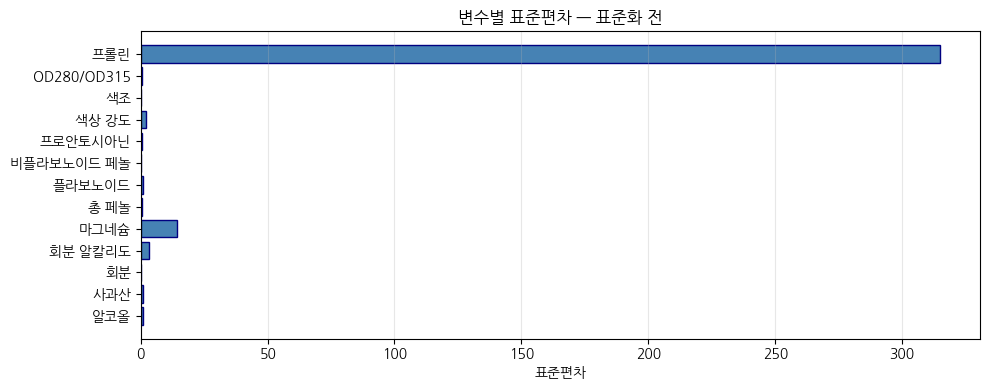

In [10]:
# 변수별 표준편차 시각화 — 스케일 불균형 한눈에 파악
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(feature_names_kr, stats_df['표준편차'], color='steelblue', edgecolor='navy')
ax.set_xlabel('표준편차')
ax.set_title('변수별 표준편차 — 표준화 전')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 1-3. 데이터 표준화 (Standardization)

$$z = \frac{x - \mu}{\sigma}$$

표준화 후 각 변수의 평균 = 0, 표준편차 = 1 → **단위 통일**  
- `fit_transform()`: 훈련 데이터에서 $\mu$, $\sigma$ 추정 후 변환  
- PCA는 분산이 큰 방향을 찾으므로 스케일 통일이 결과를 좌우함

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df[feature_names_kr].values
X_scaled = scaler.fit_transform(X)

# 표준화 확인: 각 변수의 평균 ≈ 0, 표준편차 ≈ 1
print("표준화 후 각 변수의 기초 통계")
print(f"{'변수':<22} {'평균':>8} {'표준편차':>10}")
print("-" * 44)
for i, name in enumerate(feature_names_kr):
    print(f"{name:<22} {X_scaled[:, i].mean():>8.4f} {X_scaled[:, i].std():>10.4f}")

표준화 후 각 변수의 기초 통계
변수                           평균       표준편차
--------------------------------------------
알코올                      0.0000     1.0000
사과산                      0.0000     1.0000
회분                      -0.0000     1.0000
회분 알칼리도                 -0.0000     1.0000
마그네슘                    -0.0000     1.0000
총 페놀                    -0.0000     1.0000
플라보노이드                   0.0000     1.0000
비플라보노이드 페놀              -0.0000     1.0000
프로안토시아닌                 -0.0000     1.0000
색상 강도                   -0.0000     1.0000
색조                       0.0000     1.0000
OD280/OD315              0.0000     1.0000
프롤린                     -0.0000     1.0000


### 1-4. PCA 수행 — 전체 주성분 계산

13개 변수 → 13개 주성분.  
각 주성분의 **고유값**과 **분산 설명 비율**을 먼저 확인하여 적절한 주성분 개수를 결정한다.

| 제약 조건 | 내용 |
|---|---|
| $\|\mathbf{a}_k\| = 1$ | 단위 벡터 |
| $\mathbf{a}_k^\top \mathbf{a}_l = 0$ ($k \neq l$) | PC들 간 직교 |
| 결정 방법 | 공분산 행렬의 고유벡터 |

In [12]:
from sklearn.decomposition import PCA

# n_components 지정하지 않으면 전체 주성분 계산
pca_full = PCA()
pca_full.fit(X_scaled)

pca_full

PCA()

In [13]:
eigenvalues = pca_full.explained_variance_
var_ratio   = pca_full.explained_variance_ratio_
cum_var     = np.cumsum(var_ratio)

pca_table = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(eigenvalues))],
    '고유값 (λ)': eigenvalues.round(2),
    '분산 설명 비율 (%)': (var_ratio * 100).round(1),
    '누적 분산 (%)': (cum_var * 100).round(1)
})
pca_table

,PC,고유값 (λ),분산 설명 비율 (%),누적 분산 (%)
0,PC1,4.73,36.2,36.2
1,PC2,2.51,19.2,55.4
2,PC3,1.45,11.1,66.5
3,PC4,0.92,7.1,73.6
4,PC5,0.86,6.6,80.2
5,PC6,0.65,4.9,85.1
6,PC7,0.55,4.2,89.3
7,PC8,0.35,2.7,92.0
8,PC9,0.29,2.2,94.2
9,PC10,0.25,1.9,96.2


### 1-5. 주성분 개수 결정 — Scree Plot

세 가지 기준을 함께 적용해 주성분 개수를 결정한다.

| 기준 | 설명 |
|---|---|
| **Kaiser 기준** | 고유값 $\lambda > 1$인 주성분 선택 |
| **Scree Plot 팔꿈치** | 기울기가 급격히 완만해지는 지점 |
| **누적 분산** | 전체의 70~80% 이상 설명하는 최소 개수 |

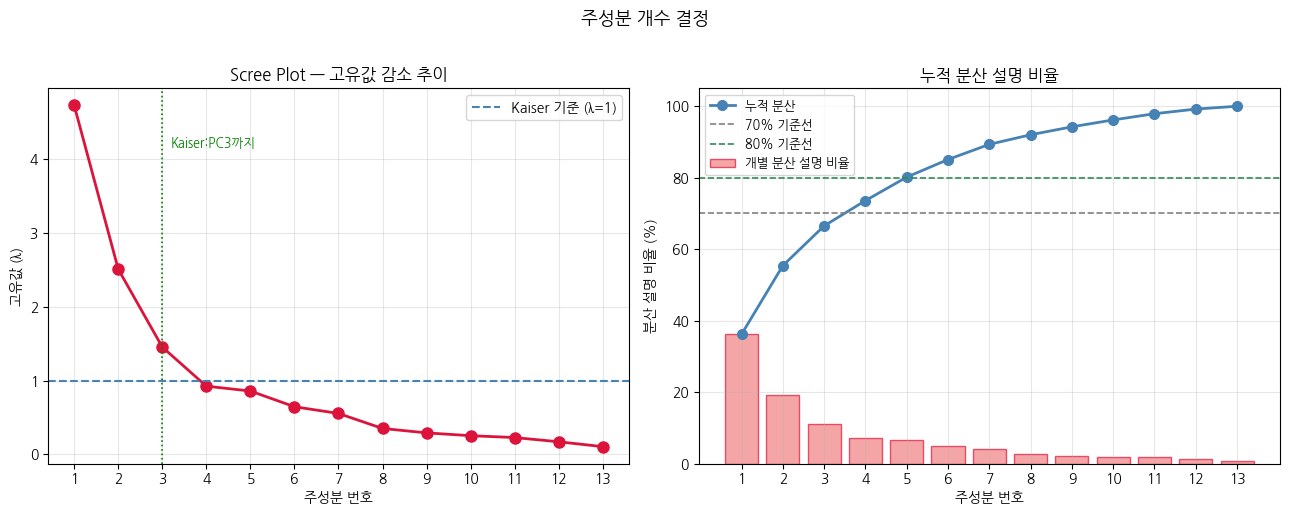

Kaiser 기준 (λ > 1): PC 3개 선택
PC          고유값      분산(%)      누적(%)
--------------------------------------
PC1        4.73       36.2       36.2
PC2        2.51       19.2       55.4
PC3        1.45       11.1       66.5


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x_ticks = np.arange(1, len(eigenvalues) + 1)

# --- 왼쪽: Scree Plot (고유값 감소 추이) ---
ax = axes[0]
ax.plot(x_ticks, eigenvalues, 'o-', color='crimson', linewidth=2, markersize=8)
ax.axhline(1, color='steelblue', linestyle='--', linewidth=1.5, label='Kaiser 기준 (λ=1)')
ax.set_xlabel('주성분 번호')
ax.set_ylabel('고유값 (λ)')
ax.set_title('Scree Plot — 고유값 감소 추이')
ax.set_xticks(x_ticks)
ax.legend()
ax.grid(True, alpha=0.3)

# Kaiser 기준 통과 지점 표시
n_kaiser = int((eigenvalues > 1).sum())
ax.axvline(n_kaiser, color='green', linestyle=':', linewidth=1.2)
ax.text(n_kaiser + 0.2, eigenvalues.max() * 0.88,
        f'Kaiser:PC{n_kaiser}까지', color='green', fontsize=9)

# --- 오른쪽: 분산 설명 비율 (막대 + 누적) ---
ax2 = axes[1]
ax2.bar(x_ticks, var_ratio * 100, color='lightcoral', edgecolor='crimson',
        alpha=0.7, label='개별 분산 설명 비율')
ax2.plot(x_ticks, cum_var * 100, 'o-', color='steelblue',
         linewidth=2, markersize=7, label='누적 분산')
ax2.axhline(70, color='gray', linestyle='--', linewidth=1.2, label='70% 기준선')
ax2.axhline(80, color='seagreen', linestyle='--', linewidth=1.2, label='80% 기준선')
ax2.set_xlabel('주성분 번호')
ax2.set_ylabel('분산 설명 비율 (%)')
ax2.set_title('누적 분산 설명 비율')
ax2.set_xticks(x_ticks)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('주성분 개수 결정', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Kaiser 기준 (λ > 1): PC {n_kaiser}개 선택")
print(f"{'PC':<6} {'고유값':>8} {'분산(%)':>10} {'누적(%)':>10}")
print("-" * 38)
for i in range(n_kaiser):
    print(f"PC{i+1:<4} {eigenvalues[i]:>8.2f} {var_ratio[i]*100:>10.1f} {cum_var[i]*100:>10.1f}")

### 1-6. PCA 2차원 변환 및 시각화

PC1·PC2 두 주성분으로 178개 와인 샘플을 **2차원 평면**에 투영.  
클래스 레이블을 사용하지 않는 **비지도 변환**이지만, 품종별 군집이 명확히 분리됨을 확인한다.

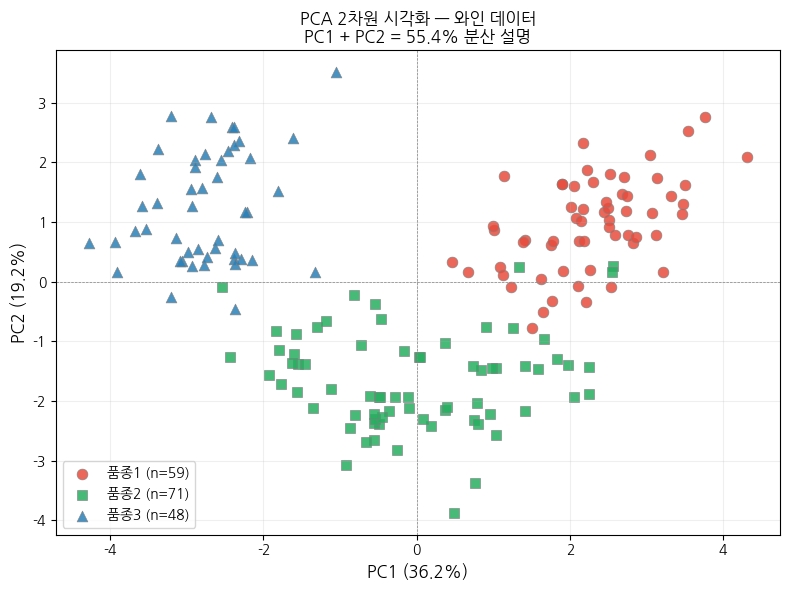

PC1: 36.2%,  PC2: 19.2%,  합계: 55.4%


In [15]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

pc1_var = pca2.explained_variance_ratio_[0] * 100
pc2_var = pca2.explained_variance_ratio_[1] * 100

fig, ax = plt.subplots(figsize=(8, 6))
colors  = ['#E74C3C', '#27AE60', '#2980B9']
markers = ['o', 's', '^']

for cls in range(3):
    mask = (df['품종'] == cls).values
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=colors[cls], marker=markers[cls],
               s=60, edgecolors='gray', linewidths=0.5,
               label=f'품종{cls+1} (n={mask.sum()})', alpha=0.85)

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({pc1_var:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pc2_var:.1f}%)', fontsize=12)
ax.set_title(f'PCA 2차원 시각화 — 와인 데이터\n'
             f'PC1 + PC2 = {pc1_var + pc2_var:.1f}% 분산 설명', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"PC1: {pc1_var:.1f}%,  PC2: {pc2_var:.1f}%,  합계: {pc1_var + pc2_var:.1f}%")

### 1-7. 주성분 적재량 (Loadings) 분석

적재량 $a_{kj}$: $j$번째 변수가 $k$번째 주성분에 기여하는 **가중치**.
- **양(+)**: 해당 변수와 주성분이 같은 방향
- **음(−)**: 반대 방향
- 절댓값이 클수록 영향력이 큼 → 주성분의 **실질적 의미** 해석에 활용

In [16]:
# pca.components_: shape = (n_components, n_features)
# 전치하면 행=변수, 열=주성분
loadings = pd.DataFrame(
    pca2.components_.T,
    index=feature_names_kr,
    columns=['PC1', 'PC2']
)

print("PC1 적재량 상위 변수 (절댓값 기준)")
print(loadings['PC1'].abs().sort_values(ascending=False).round(3).to_frame())
print()
print("PC2 적재량 상위 변수 (절댓값 기준)")
print(loadings['PC2'].abs().sort_values(ascending=False).round(3).head(5).to_frame())

PC1 적재량 상위 변수 (절댓값 기준)
               PC1
플라보노이드       0.423
총 페놀         0.395
OD280/OD315  0.376
프로안토시아닌      0.313
비플라보노이드 페놀   0.299
색조           0.297
프롤린          0.287
사과산          0.245
회분 알칼리도      0.239
알코올          0.144
마그네슘         0.142
색상 강도        0.089
회분           0.002

PC2 적재량 상위 변수 (절댓값 기준)
         PC2
색상 강도  0.530
알코올    0.484
프롤린    0.365
회분     0.316
마그네슘   0.300


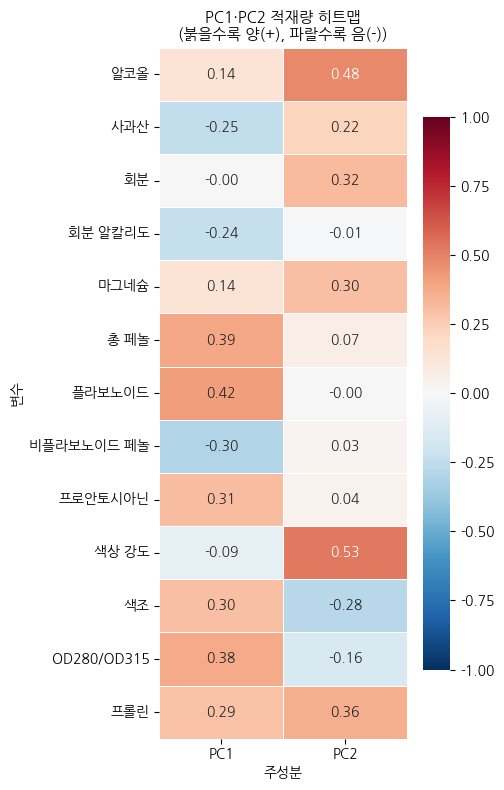

In [17]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.heatmap(
    loadings.round(2),
    annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0, ax=ax,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax.set_title('PC1·PC2 적재량 히트맵\n(붉을수록 양(+), 파랄수록 음(-))', fontsize=11)
ax.set_xlabel('주성분')
ax.set_ylabel('변수')
plt.tight_layout()
plt.show()

---
## PART 2. K-means 클러스터링

데이터를 **레이블(정답) 없이** 유사한 개체끼리 그룹화하는 **비지도학습**.  

**K-means 알고리즘 순서**:
1. **초기화**: $K$개의 중심점(centroid)을 임의 선택
2. **배정**: 각 데이터를 가장 가까운 중심점의 군집에 할당
3. **갱신**: 각 군집의 평균으로 중심점 업데이트
4. **반복**: 중심점이 더 이상 변하지 않을 때까지 2–3 반복

**거리 척도 (유클리드 거리)**:
$$d(\mathbf{x}, \boldsymbol{\mu}_k) = \sqrt{\sum_{j=1}^{p}(x_j - \mu_{kj})^2}$$

### 2-1. K=3으로 K-means 클러스터링

와인 품종이 3개임을 알고 있으므로 K=3으로 먼저 실습.  
`n_init=10`: 서로 다른 초기값으로 10번 실행 → 초기값 민감성 보완

In [18]:
kmeans_k3 = KMeans(n_clusters=3, n_init=10, random_state=42)
cluster_labels = kmeans_k3.fit_predict(X_scaled)

df['군집'] = cluster_labels

print(f"WCSS (군집 내 제곱합): {kmeans_k3.inertia_:.2f}")
print(f"군집별 샘플 수:")
print(pd.Series(cluster_labels).value_counts().sort_index()
        .rename(index=lambda x: f'군집{x}'))

WCSS (군집 내 제곱합): 1277.93
군집별 샘플 수:
군집0    65
군집1    51
군집2    62
Name: count, dtype: int64


### 2-2. 최적 K 선택 — Elbow Method

군집 내 응집도를 측정하는 **WCSS** (Within-Cluster Sum of Squares):

$$\text{WCSS} = \sum_{k=1}^{K} \sum_{\mathbf{x} \in C_k} \| \mathbf{x} - \boldsymbol{\mu}_k \|^2$$

- K가 증가할수록 WCSS 감소 (군집이 세분화)
- **감소 속도가 급격히 둔화되는 지점** = 최적 K
- 그래프 모양이 팔꿈치(elbow) 형태 → 이름 유래

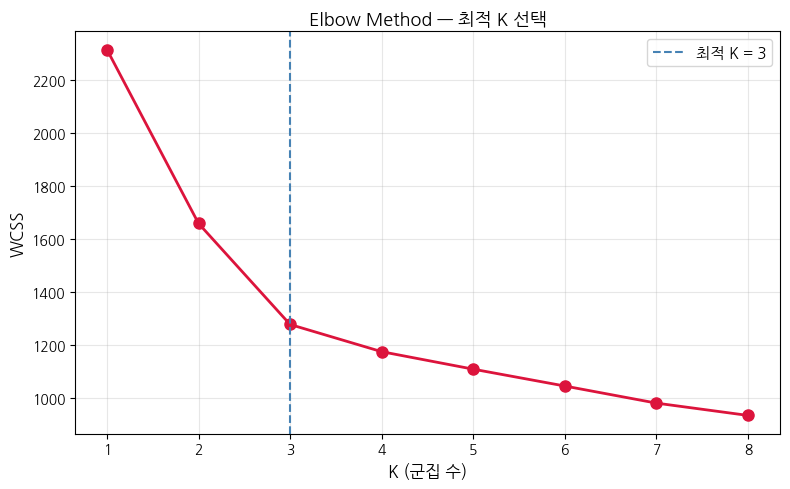

K별 WCSS:
  K=1: 2314.0
  K=2: 1658.8
  K=3: 1277.9
  K=4: 1175.4
  K=5: 1109.5
  K=6: 1046.0
  K=7: 981.6
  K=8: 935.2


In [19]:
wcss_list = []
K_range = range(1, 9)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss_list.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, wcss_list, 'o-', color='crimson', linewidth=2, markersize=8)
ax.axvline(3, color='steelblue', linestyle='--', linewidth=1.5, label='최적 K = 3')
ax.set_xlabel('K (군집 수)', fontsize=12)
ax.set_ylabel('WCSS', fontsize=12)
ax.set_title('Elbow Method — 최적 K 선택', fontsize=13)
ax.set_xticks(list(K_range))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("K별 WCSS:")
for k, w in zip(K_range, wcss_list):
    print(f"  K={k}: {w:.1f}")

### 2-3. PCA + K-means 결합

**결합 전략:**
1. **PCA로 차원 축소** (13차원 → 2차원): 노이즈 제거, 계산 효율 향상
2. **저차원 주성분 공간에서 K-means 군집화**
3. **PC1–PC2 산점도에 군집 색상 표시** → 결과 시각화 용이

와인 데이터 파이프라인: 13차원 → PCA 2차원 → K-means (K=3) → 3개 군집 확인

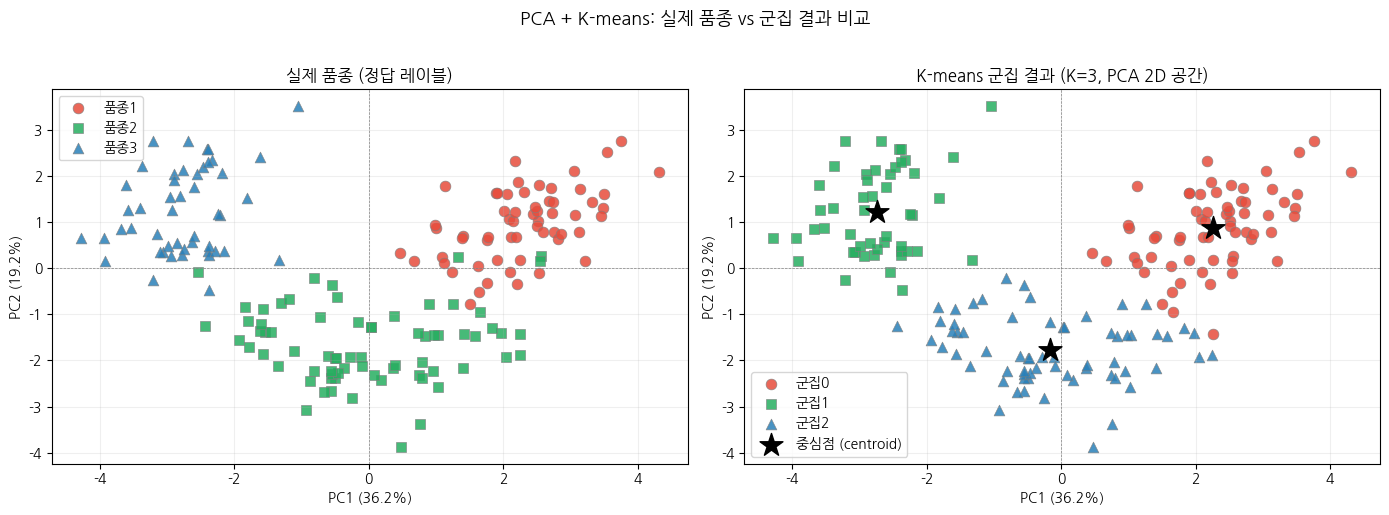

In [20]:
# PCA 2D 공간에서 K-means 적용
kmeans_pca = KMeans(n_clusters=3, n_init=10, random_state=42)
cluster_pca = kmeans_pca.fit_predict(X_pca2)
centers_pca = kmeans_pca.cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors  = ['#E74C3C', '#27AE60', '#2980B9']
markers = ['o', 's', '^']

# --- 왼쪽: 실제 품종 ---
ax = axes[0]
for cls in range(3):
    mask = (df['품종'] == cls).values
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=colors[cls], marker=markers[cls], s=60,
               edgecolors='gray', linewidths=0.5,
               label=f'품종{cls+1}', alpha=0.85)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({pc1_var:.1f}%)')
ax.set_ylabel(f'PC2 ({pc2_var:.1f}%)')
ax.set_title('실제 품종 (정답 레이블)')
ax.legend()
ax.grid(True, alpha=0.2)

# --- 오른쪽: K-means 군집 결과 ---
ax2 = axes[1]
for c in range(3):
    mask = (cluster_pca == c)
    ax2.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                c=colors[c], marker=markers[c], s=60,
                edgecolors='gray', linewidths=0.5,
                label=f'군집{c}', alpha=0.85)
ax2.scatter(centers_pca[:, 0], centers_pca[:, 1],
            marker='*', s=300, c='black', zorder=5, label='중심점 (centroid)')
ax2.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax2.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax2.set_xlabel(f'PC1 ({pc1_var:.1f}%)')
ax2.set_ylabel(f'PC2 ({pc2_var:.1f}%)')
ax2.set_title('K-means 군집 결과 (K=3, PCA 2D 공간)')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.suptitle('PCA + K-means: 실제 품종 vs 군집 결과 비교', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 2-4. 군집 결과 평가 — 실제 품종과 비교

> K-means는 **비지도학습** — 클래스 레이블 없이 군집화.  
> 군집 번호(0, 1, 2)는 임의 배정이므로 실제 품종과 자동으로 일치하지 않는다.  
> **교차표(crosstab)**로 군집과 실제 품종의 대응 관계를 확인한다.

In [21]:
# 13차원 전체 데이터로 군집화한 결과 vs 실제 품종
print("=== 13차원 K-means 군집 vs 실제 품종 ===")
ct_13d = pd.crosstab(
    df['품종명'],
    pd.Series(cluster_labels, name='군집 (13차원)').map(lambda x: f'군집{x}')
)
print(ct_13d)

print()
print("=== PCA 2D K-means 군집 vs 실제 품종 ===")
ct_pca = pd.crosstab(
    df['품종명'],
    pd.Series(cluster_pca, name='군집 (PCA 2D)').map(lambda x: f'군집{x}')
)
print(ct_pca)

print()
print("각 행(실제 품종)에서 가장 많이 배정된 군집이 해당 품종과 대응됨")
print("→ 대각선에 값이 집중될수록 군집이 품종 구조를 잘 복원한 것")

=== 13차원 K-means 군집 vs 실제 품종 ===
군집 (13차원)  군집0  군집1  군집2
품종명                     
품종1          0    0   59
품종2         65    3    3
품종3          0   48    0

=== PCA 2D K-means 군집 vs 실제 품종 ===
군집 (PCA 2D)  군집0  군집1  군집2
품종명                       
품종1           59    0    0
품종2            5    1   65
품종3            0   48    0

각 행(실제 품종)에서 가장 많이 배정된 군집이 해당 품종과 대응됨
→ 대각선에 값이 집중될수록 군집이 품종 구조를 잘 복원한 것


---
## 요약

### 핵심 개념

| 개념 | 설명 | 주요 함수/속성 |
|---|---|---|
| **StandardScaler** | 평균 0, 표준편차 1로 표준화 — PCA 전 필수 | `StandardScaler().fit_transform()` |
| **PCA** | 분산이 최대인 방향으로 직교 변환, 차원 축소 | `PCA(n_components=k)` |
| **고유값 (λ)** | 각 주성분이 설명하는 분산 크기 | `pca.explained_variance_` |
| **Kaiser 기준** | $\lambda > 1$인 주성분만 선택 | — |
| **Scree Plot** | 고유값 감소 추이 시각화 — 팔꿈치 지점 찾기 | — |
| **적재량** | 원래 변수 → 주성분 기여 가중치 | `pca.components_.T` |
| **KMeans** | K개 중심점 기반 반복 군집화 | `KMeans(n_clusters=K, n_init=10)` |
| **WCSS** | 군집 내 제곱합 — 낮을수록 응집도 높음 | `kmeans.inertia_` |
| **Elbow Method** | WCSS 감소 속도 둔화 지점 = 최적 K | — |

### 실습 데이터 결과 요약 (와인 데이터, 178개 샘플, 13개 변수)

- **PCA 분산 설명**: PC1(36.2%) + PC2(19.2%) = 55.4% / Kaiser 기준 PC 3개 (66%)
- **PC1 주요 기여 변수**: 플라보노이드·OD280/OD315·총 페놀 (양) → '품질 지표' 축
- **K-means (K=3)**: Elbow Method에서 K=3이 팔꿈치 지점 → 실제 3품종 구조 재현
- **PCA + K-means**: 2차원 축소 후 군집화해도 품종 분리 재현 — 시각화 용이

> **비지도학습의 한계**: 군집 번호는 임의 배정 → 실제 품종과 1:1 대응은 교차표로 수동 확인  
> **표준화 필수**: 단위·스케일이 혼재할 때 PCA 전 반드시 표준화 적용 (평균 0, 분산 1)